# Language detection - Naive Bayes

# 1. Data import

In [1]:
import pandas as pd
import csv

In [180]:
# Set option to display more content in cells
pd.set_option('display.max_colwidth', 500)

In [216]:
# Import dataset and organize df
lang_df = pd.read_csv(
    'Language_Detection.csv', encoding='utf-8', delimiter=',',
    quotechar='\"', quoting=csv.QUOTE_MINIMAL)

lang_df.head(2)

,Text,Language
0,"Nature, in the broadest sense, is the natural, physical, material world or universe.",English
1,"""Nature"" can refer to the phenomena of the physical world, and also to life in general.",English


# 2. EDA and data cleaning

## 2.2 EDA

In [217]:
lang_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10337 entries, 0 to 10336
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      10337 non-null  object
 1   Language  10337 non-null  object
dtypes: object(2)
memory usage: 161.6+ KB


In [218]:
# Check count and unique
lang_df.describe()

,Text,Language
count,10337,10337
unique,10267,17
top,Jag är ledsen.,English
freq,3,1385


In [219]:
# Check unique categories
lang_df["Language"].unique()

array(['English', 'Malayalam', 'Hindi', 'Tamil', 'Portugeese', 'French',
       'Dutch', 'Spanish', 'Greek', 'Russian', 'Danish', 'Italian',
       'Turkish', 'Sweedish', 'Arabic', 'German', 'Kannada'], dtype=object)

In [220]:
# Check for empty category cells
lang_df["Language"].isna().sum()

0

In [221]:
# Check for duplicates
full_duplicates  = lang_df.duplicated().sum()
full_duplicates

66

In [222]:
# Drop duplicates
lang_df = lang_df.drop_duplicates()

In [223]:
# Check for again for duplicates
lang_df.duplicated().sum()

0

In [224]:
# Check for duplicates in Text col
lang_df["Text"].duplicated().sum()

4

In [225]:
# Find duplicate index
duplicated_text=lang_df["Text"].duplicated()
# Create df with index numbers in first col and transform the col to a list
duplicated_df = duplicated_text.loc[duplicated_text==True].to_frame().reset_index()
duplicated_list = duplicated_df["index"].tolist()
duplicated_list

[4151, 4649, 5359, 8823]

In [226]:
# Find duplicate rows based on indexlist
lang_df.loc[duplicated_list,:].head()

,Text,Language
4151,suggestions.,French
4649,pardon?,Dutch
5359,dedos cruzados.,Spanish
8823,slår mig.,Sweedish


In [227]:
# Drop rows containing whose index is in duplicated_list
lang_df = lang_df.drop(duplicated_list)

In [228]:
# Check again for duplicates -> 0
lang_df["Text"].duplicated().sum()

0

In [229]:
# Check again count and unique
lang_df["Text"].describe().to_frame()

,Text
count,10267
unique,10267
top,"Nature, in the broadest sense, is the natural, physical, material world or universe."
freq,1


In [230]:
# List of categories
lang_df["Language"].unique().tolist()

['English',
 'Malayalam',
 'Hindi',
 'Tamil',
 'Portugeese',
 'French',
 'Dutch',
 'Spanish',
 'Greek',
 'Russian',
 'Danish',
 'Italian',
 'Turkish',
 'Sweedish',
 'Arabic',
 'German',
 'Kannada']

In [231]:
# Count articles per category
lang_df["Language"].value_counts()

English       1382
French        1006
Spanish        815
Portugeese     736
Italian        694
Russian        688
Sweedish       672
Malayalam      591
Dutch          541
Arabic         532
Turkish        471
German         465
Tamil          464
Danish         424
Kannada        366
Greek          358
Hindi           62
Name: Language, dtype: int64

In [232]:
# Add col with number of words for each article
lang_df['WordCount'] = lang_df['Text'].str.split().str.len()
lang_df.head(3)

,Text,Language,WordCount
0,"Nature, in the broadest sense, is the natural, physical, material world or universe.",English,13
1,"""Nature"" can refer to the phenomena of the physical world, and also to life in general.",English,16
2,"The study of nature is a large, if not the only, part of science.",English,14


Total word count:


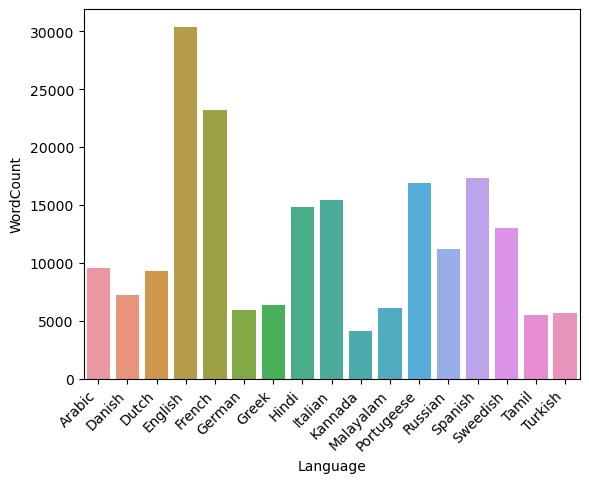

In [233]:
# Total word counts by category
counts=lang_df.groupby('Language')['WordCount'].sum().to_frame().reset_index()

# Barplot
import seaborn as sns
import matplotlib.pyplot as plt

ax=sns.barplot(x='Language', y='WordCount', data=counts)

# Tilt the bar labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

print("Total word count:")

plt.show()

# Display word counts by category as df
#counts

Average word count:


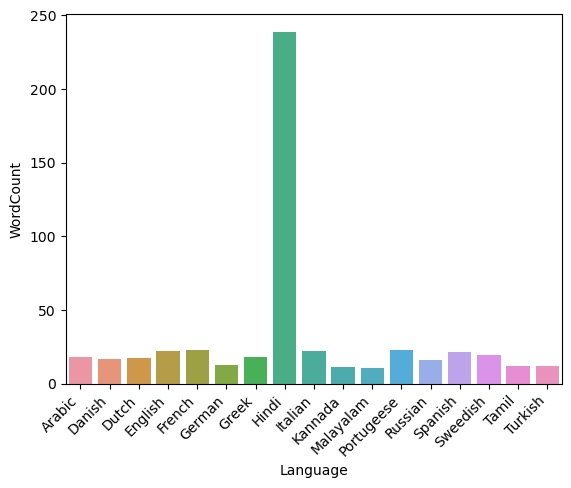

In [234]:
# Average word counts by category
avg_counts=lang_df.groupby('Language')['WordCount'].mean().to_frame().reset_index()

# Barplot
import seaborn as sns
import matplotlib.pyplot as plt

ax2=sns.barplot(x='Language', y='WordCount', data=avg_counts)

# Tilt the bar labels
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

print("Average word count:")
plt.show()

In [235]:
# Description of counts by category
desc=lang_df.groupby('Language')['WordCount'].describe()
desc

,count,mean,std,min,25%,50%,75%,max
Language,,,,,,,,
Arabic,532.0,17.975564,13.985780,1.0,8.00,15.0,24.00,95.0
Danish,424.0,16.995283,16.180862,1.0,6.00,12.5,23.00,142.0
Dutch,541.0,17.251386,14.830762,1.0,7.00,14.0,23.00,146.0
English,1382.0,21.989870,13.454724,1.0,13.00,20.0,29.00,142.0
French,1006.0,23.098410,16.291720,1.0,12.00,21.0,30.00,156.0
German,465.0,12.701075,10.365669,1.0,5.00,10.0,18.00,76.0
Greek,358.0,17.851955,16.305311,1.0,5.00,14.0,26.00,127.0
Hindi,62.0,238.822581,556.506006,4.0,10.25,41.0,250.75,3735.0
Italian,694.0,22.250720,17.724050,1.0,9.00,19.0,31.00,144.0


## 2.3 Selection of languages

In [236]:
# Create copy of lang_df to be used for language selection
lang_sel_df=lang_df.copy()

In [237]:
# Select data from German, English, French, Spanish, Italian
lang_list = ["German", "English", "French", "Spanish"]
lang_sel_df = lang_sel_df.loc[lang_sel_df["Language"].isin(lang_list),:]

In [239]:
lang_sel_df["Language"].unique().tolist()

['English', 'French', 'Spanish', 'German']

# 3. Text preprocessing

In [240]:
# Create copy of lang_sel_df to be used for text preprocessing
lang_df_prep = lang_sel_df.copy()

## 3.1 Text cleaning

Removing HTML tags, special characters, punctuation, numbers, and extra whitespaces (but not replaceing umlauts and ß)

In [241]:
import re

# Function: remove HTML tags
def remove_html_tags(text):
    clean_text = re.sub('<.*?>', '', text)
    return clean_text

# Function: remove special characters, numbers, and punctuation
def remove_special_characters(text):
    clean_text = re.sub(r'[^a-zA-Z\sßüöä]', '', text)
    return clean_text

# Function: convert text to lowercase
def convert_to_lowercase(text):
    return text.lower()

# Function: remove extra whitespace
def remove_extra_whitespace(text):
    clean_text = re.sub(r'\s+', ' ', text)
    return clean_text.strip()

# Apply text cleaning steps to 'text' column
lang_df_prep['text_cleaned'] = lang_df_prep['Text'].apply(lambda x: remove_html_tags(x))
lang_df_prep['text_cleaned'] = lang_df_prep['text_cleaned'].apply(lambda x: remove_special_characters(x))
lang_df_prep['text_cleaned'] = lang_df_prep['text_cleaned'].apply(lambda x: convert_to_lowercase(x))
lang_df_prep['text_cleaned'] = lang_df_prep['text_cleaned'].apply(lambda x: remove_extra_whitespace(x))

lang_df_prep.tail(2)


,Text,Language,WordCount,text_cleaned
9966,"Terry, du siehst tatsächlich ein bisschen wie dieser Engel aus, aber was sehe ich, wie könntest du er sein?",German,19,terry du siehst tatsächlich ein bisschen wie dieser engel aus aber was sehe ich wie könntest du er sein
9967,Ihr zwei seid so nett,German,5,ihr zwei seid so nett


## Subdivision of dataframes

In [242]:
# Subdivide df by language (and later concatenate again)
lang_df_prep_de = lang_df_prep.loc[lang_df_prep["Language"]=="German",:]
lang_df_prep_en = lang_df_prep.loc[lang_df_prep["Language"]=="English",:]
lang_df_prep_fr = lang_df_prep.loc[lang_df_prep["Language"]=="French",:]
lang_df_prep_es = lang_df_prep.loc[lang_df_prep["Language"]=="Spanish",:]

## 3.2 Lemmatization (not applied any more)

In [243]:
import spacy as sp

In [244]:
# Load language models
nlp_en = sp.load("en_core_web_sm")
nlp_de = sp.load("de_core_news_sm")
nlp_fr = sp.load("fr_core_news_sm")
nlp_es = sp.load("es_core_news_sm")

In [ ]:
# Lemmatize texts for each language

# German:
def lemmatize_text_de(text):
    doc = nlp_de(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)

# English:
def lemmatize_text_en(text):
    doc = nlp_en(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)

# French:
def lemmatize_text_fr(text):
    doc = nlp_fr(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)

# Spanish:
def lemmatize_text_es(text):
    doc = nlp_es(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)


lang_df_prep_de["text_lemmatized"] = lang_df_prep_de["text_cleaned"].apply(lemmatize_text_de)
lang_df_prep_en["text_lemmatized"] = lang_df_prep_en["text_cleaned"].apply(lemmatize_text_en)
lang_df_prep_fr["text_lemmatized"] = lang_df_prep_fr["text_cleaned"].apply(lemmatize_text_fr)
lang_df_prep_es["text_lemmatized"] = lang_df_prep_es["text_cleaned"].apply(lemmatize_text_es)


In [ ]:
# Check lemmatization for each language
lang_df_prep_de
#lang_df_prep_en
#lang_df_prep_fr
#lang_df_prep_es

## 3.3 Stopword removal

In [ ]:
import spacy as sp

In [248]:
# Load language models (also applied above)
nlp_en = sp.load("en_core_web_sm")
nlp_de = sp.load("de_core_news_sm")
nlp_fr = sp.load("fr_core_news_sm")
nlp_es = sp.load("es_core_news_sm")

In [ ]:
# Stopword removal

# German:
def remove_stopwords_de(text):
    doc = nlp_de(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

# English:
def remove_stopwords_en(text):
    doc = nlp_en(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

# French:
def remove_stopwords_fr(text):
    doc = nlp_fr(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

# French:
def remove_stopwords_es(text):
    doc = nlp_es(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

# Call function, adding a new col to df
lang_df_prep_de['text_stopwords_removed'] = lang_df_prep_de['text_cleaned'].apply(remove_stopwords_de)
lang_df_prep_en['text_stopwords_removed'] = lang_df_prep_en['text_cleaned'].apply(remove_stopwords_en)
lang_df_prep_fr['text_stopwords_removed'] = lang_df_prep_fr['text_cleaned'].apply(remove_stopwords_fr)
lang_df_prep_es['text_stopwords_removed'] = lang_df_prep_es['text_cleaned'].apply(remove_stopwords_es)


## Concatenation of dataframes

In [ ]:
# Concatenate df
# concatenated = pd.concat([df1, df2], axis=0)
lang_df_prep =  pd.concat(
    [lang_df_prep_de, lang_df_prep_en, lang_df_prep_fr, lang_df_prep_es], axis=0)
lang_df_prep

1. Text Cleaning:
- Remove HTML tags (if present).
- Remove special characters and symbols that are not relevant to the analysis.
- Remove punctuation marks.
- Remove any URLs or hyperlinks.

2. Tokenization:
- Split the text into individual words or tokens. 
- Consider using a tokenizer specifically designed for German text, such as the tokenizer provided by the Natural Language Toolkit (NLTK) or the SpaCy library.

3. Lowercasing:
- Convert all text to lowercase. This ensures that words with the same meaning but different cases are treated as the same.

4. Stopword Removal:
- Remove common German stopwords (e.g., "und", "oder", "aber") that do not carry significant meaning and may not contribute much to the classification task.
- Consider using a predefined list of German stopwords or a library like NLTK or SpaCy that provides stopwords for multiple languages.

5. Lemmatization or Stemming:
- Apply lemmatization or stemming to reduce words to their base or root form.
- Choose between lemmatization (preferable for accuracy and interpretability) or stemming (faster but less linguistically accurate).
- Utilize a German-specific lemmatizer or stemmer, such as those available in SpaCy or the Snowball stemmer for German.

6. Removal of Rare or Frequent Words:
- Remove very rare or very frequent words that may not provide much discriminatory power in classification.
- Consider setting thresholds based on the document frequency or term frequency-inverse document frequency (TF-IDF) values to filter out such words.

7. Handling German-specific Challenges:
- Address German-specific challenges like compound words, umlauts, and diacritical marks.
- Consider preprocessing steps such as splitting compound words, handling umlauts, and normalizing diacritical marks to ensure consistency.

8. Vectorization:
- Convert the preprocessed text into numerical features that can be used as input for machine learning algorithms.
- Common techniques include bag-of-words (BoW), TF-IDF, or word embeddings like Word2Vec or GloVe.

# 4. Train-test split

In [251]:
# Copy df before further processing
lang_df_split = lang_df_prep.copy()

## 4.1 Remove columns

In [252]:
# Remove col not required
lang_df_split = lang_df_split[['Language', 'text_stopwords_removed']]
lang_df_split.head(2)

,Language,text_stopwords_removed
9498,German,suche schnellen fließender englisch sprechen
9499,German,weiß verstehe passiert paar worte gehirn umkreisen gesamte unterhaltung einfach unglaublich cool episch führen


## 4.2 Define X and y

In [253]:
# Define y
y = lang_df_split.pop("Language")

# print(y.tolist())

In [254]:
# Define X
X = lang_df_split
X.head(2)

,text_stopwords_removed
9498,suche schnellen fließender englisch sprechen
9499,weiß verstehe passiert paar worte gehirn umkreisen gesamte unterhaltung einfach unglaublich cool episch führen


## 4.3 Split

In [255]:
from sklearn.model_selection import train_test_split

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)


In [256]:
len(X_train)

3301

In [257]:
len(y_train)

3301

# 5. Support Vector Machine

In [271]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.feature_selection import RFE
from nltk.tokenize import word_tokenize

## 5.1 Create pipeline and fit training data

In [272]:
# Define the pipeline
my_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(analyzer='char_wb')), # , ngram_range=(1, 3)
    ('classifier', MultinomialNB())
])

# Fit the pipeline to the training data
my_pipeline.fit(X_train["text_stopwords_removed"], y_train)


Pipeline(steps=[('vectorizer', CountVectorizer(analyzer='char_wb')),
                ('classifier', MultinomialNB())])

In [273]:
# Vectorization and prediction for training data
my_pipeline.predict(X_train["text_stopwords_removed"])

array(['English', 'French', 'German', ..., 'English', 'French', 'Spanish'],
      dtype='<U7')

## 5.2 Cross-validation

In [1]:
param_grid = {
    'vectorizer__max_features': (None, 5000, 10000, 50000),
    'vectorizer__ngram_range': ((1, 1), (1, 2)),  # unigrams or bigrams
    'classifier__alpha': (0.1, 1, 10),
}

In [275]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(my_pipeline,
                      param_grid,
                      cv=5,
                      scoring='accuracy'
                     )


In [276]:
# Fit "search" to training data (X and y)
search.fit(X_train["text_stopwords_removed"], y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vectorizer',
                                        CountVectorizer(analyzer='char_wb')),
                                       ('classifier', MultinomialNB())]),
             param_grid={'classifier__alpha': (0.1, 1, 10),
                         'vectorizer__max_features': (None, 5000, 10000, 50000),
                         'vectorizer__ngram_range': ((1, 1), (1, 2))},
             scoring='accuracy')

In [277]:
search.best_params_

{'classifier__alpha': 0.1,
 'vectorizer__max_features': None,
 'vectorizer__ngram_range': (1, 2)}

In [278]:
# Save trained model to file
import pickle

with open('my_lang_model.pkl', 'wb') as file:
    pickle.dump(search, file)

## 5.3 Metrics

In [168]:
from sklearn.metrics import accuracy_score

In [279]:
# Accuracy for training data
y_train_pred = search.predict(X_train["text_stopwords_removed"])
#y_train_pred = my_pipeline.predict(X_train["text_stopwords_removed"])

accuracy_score(y_train, y_train_pred)

0.9342623447440169

In [280]:
# Accuracy for test data
y_test_pred = search.predict(X_test["text_stopwords_removed"])
#y_test_pred = my_pipeline.predict(X_test["text_stopwords_removed"])

accuracy_score(y_test, y_test_pred)

0.9482288828337875

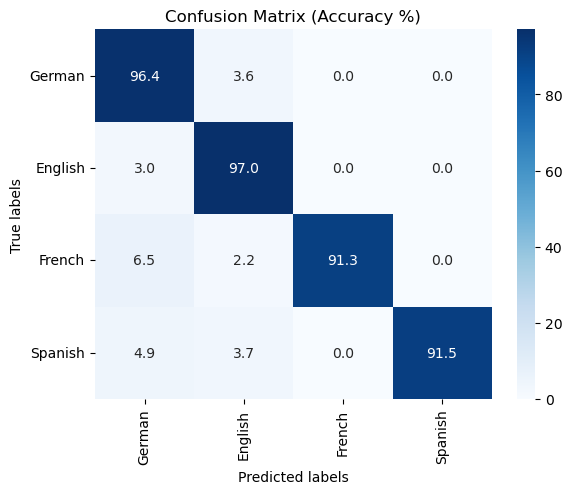

In [281]:
# Confusion matrix for accuracy

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming you have true labels and predicted labels for your test data
true_labels = y_test
predicted_labels = y_test_pred

# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create a list of class labels (optional, if you have class labels)
class_labels = lang_df_prep["Language"].unique().tolist()  # List of class labels in the order of the confusion matrix

# Create a heatmap using seaborn
sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.1f')

# Add labels, title, and axis ticks
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Accuracy %)')
plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=90)
plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)

# Create tick labels with class names
tick_labels = class_labels
#tick_labels = [f'{class_labels[i]} ({i})' for i in range(len(class_labels))]
plt.xticks(np.arange(len(class_labels)) + 0.5, tick_labels, rotation=90)
plt.yticks(np.arange(len(class_labels)) + 0.5, tick_labels, rotation=0)

# Display the plot
plt.show()


# 6. Input classification

In [300]:
# Open model from file
import pickle
with open('my_lang_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [384]:
# Input text for instant classification
new_text = input("Enter text: ")

# Clean input text
clean_text = re.sub('<.*?>', '', new_text) # Remove HTML tags
clean_text = re.sub(r'[^\w\s]|_|[0-9]', '', clean_text) # Remove punctuation and special characters
clean_text = clean_text.lower() # lowercasing
clean_text = re.sub(r'\s+', ' ', clean_text) # remove extra whitespace
clean_text = clean_text.strip()

# Make prediction
prediction = loaded_model.predict([clean_text])
print(f'\nLanguage: {prediction[0]}')



Enter text:  Das Oberlandesgericht Dresden hat die mutmaßliche Linksextremistin Lina E. zu einer mehrjährigen Freiheitsstrafe verurteilt. Nach Auffassung des Gerichts gehörte sie einer Gruppe an, die Überfälle auf Mitglieder der rechten Szene begangen hat.Im Prozess gegen die mutmaßliche Linksextremistin Lina E. und drei weitere Angeklagte hat das sächsische Oberlandesgericht in Dresden mehrjährige Haftstrafen verhängt. Es verurteilte die 28-Jährige unter anderem wegen der Mitgliedschaft in einer kriminellen Vereinigung zu einer Freiheitsstrafe von fünf Jahren und drei Monaten.Die mitangeklagten Männer erhielten Haftstrafen zwischen zwei Jahren und fünf Monaten sowie drei Jahren und drei Monaten. Einer wurde wegen Mitgliedschaft, die beiden anderen wegen Unterstützung einer kriminellen Vereinigung verurteilt.Das Urteil wurde im Gerichtssaal von etwa 100 Unterstützern der Angeklagten verfolgt. Sie hatten Lina E. und die drei Mitangeklagten mit langem Applaus begrüßt. Nach dem Urteil wur


Language: German


In [385]:
# Get the predicted probabilities
probs = loaded_model.predict_proba([new_text])

# List of languages (alphabetically ordered)
languages=sorted(lang_sel_df["Language"].unique().tolist())

# Print the probabilities
for text, prob in zip([new_text], probs):
    #print(f'Text: {text}')
    for lang, p in zip(languages, prob):
        print(f'{lang}: {round(p,3)}')
    print('\n')


English: 0.0
French: 0.0
German: 1.0
Spanish: 0.0


